/home/sammarv/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


QNN Corrosion v7 — EfficientNet Hybrid QNN + Optuna Search
Device: cuda   Workers: 8

[1/6] Loading splits...

[2/6] Memory-mapping IQ files...

[3/6] Feature extraction...
  Extracting 1848 [train]...
  200/1848 extracted...
  400/1848 extracted...
  600/1848 extracted...
  800/1848 extracted...
  1000/1848 extracted...
  1200/1848 extracted...
  1400/1848 extracted...
  1600/1848 extracted...
  1800/1848 extracted...
  1848/1848 extracted...
  Done in 6.5s
  Extracting 1233 [val]...
  200/1233 extracted...
  400/1233 extracted...
  600/1233 extracted...
  800/1233 extracted...
  1000/1233 extracted...
  1200/1233 extracted...
  1233/1233 extracted...
  Done in 4.2s
  Extracting 1233 [test]...
  200/1233 extracted...
  400/1233 extracted...
  600/1233 extracted...
  800/1233 extracted...
  1000/1233 extracted...
  1200/1233 extracted...
  1233/1233 extracted...
  Done in 4.2s

[4/6] Preprocessing (Flat) & Classical Baselines...


[I 2026-05-03 09:35:46,396] A new study created in memory with name: no-name-860b5412-f775-4fb4-a7c3-e726efc47901


  Random Forest: val_acc=0.9148 test_acc=0.9238

[5/6] Preparing 2D Spectrograms for EfficientNet...

[6/6] Starting Optuna Q-NAS (Search Space: Qubits, Layers, Ansatz, Angle)


[I 2026-05-03 09:38:40,821] Trial 0 finished with value: 0.9113338588595046 and parameters: {'n_qubits': 8, 'n_layers': 2, 'ansatz': 'StronglyEntangling', 'angle_scaling': 'pi_half'}. Best is trial 0 with value: 0.9113338588595046.
[I 2026-05-03 09:41:34,763] Trial 1 finished with value: 0.8698380399568896 and parameters: {'n_qubits': 8, 'n_layers': 2, 'ansatz': 'StronglyEntangling', 'angle_scaling': 'two_pi'}. Best is trial 0 with value: 0.9113338588595046.
[I 2026-05-03 09:44:33,976] Trial 2 finished with value: 0.896639930542667 and parameters: {'n_qubits': 6, 'n_layers': 4, 'ansatz': 'StronglyEntangling', 'angle_scaling': 'pi_half'}. Best is trial 0 with value: 0.9113338588595046.
[I 2026-05-03 09:47:43,848] Trial 3 finished with value: 0.8682095371583681 and parameters: {'n_qubits': 8, 'n_layers': 3, 'ansatz': 'StronglyEntangling', 'angle_scaling': 'pi'}. Best is trial 0 with value: 0.9113338588595046.
[I 2026-05-03 09:50:18,229] Trial 4 finished with value: 0.898538113379313 and 


BEST QUANTUM ARCHITECTURE FOUND:
  Best Val F1-Score: 0.9113
    n_qubits: 8
    n_layers: 2
    ansatz: StronglyEntangling
    angle_scaling: pi_half

Training Final Model with Best Hyperparameters...

FINAL TEST SET EVALUATION (Hybrid EfficientNet QNN)
  Accuracy: 0.9043
  F1-Score: 0.9000
  MAE:      0.1695 grams
  R-Squared:0.7158

Classification Report:
              precision    recall  f1-score   support

        0.5g       0.91      0.91      0.91       244
        1.0g       0.88      0.77      0.82       221
        1.5g       0.81      0.90      0.85       232
        2.0g       1.00      1.00      1.00       265
        2.5g       0.92      0.92      0.92       271

    accuracy                           0.90      1233
   macro avg       0.90      0.90      0.90      1233
weighted avg       0.91      0.90      0.90      1233



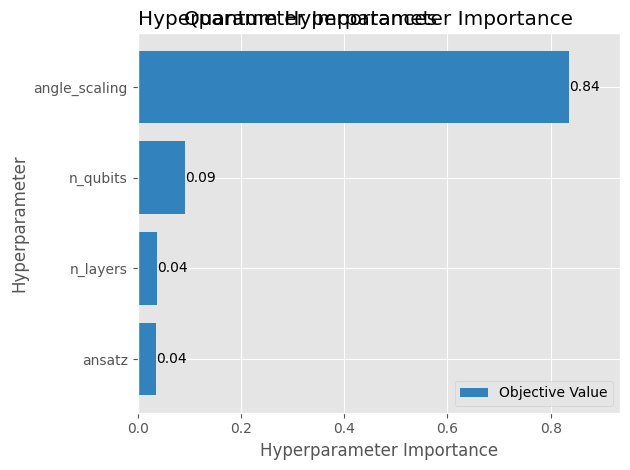

In [3]:
#!/usr/bin/env python3
"""
QNN Corrosion v7 — Raw IQ Feature Extraction + EfficientNet Hybrid QNN + Optuna Q-NAS
=============================================================================
Pipeline:
  1. Raw IQ → Full-resolution PSD + stats (1040-d) AND 2D Spectrogram (16x512)
  2. 1040-d → StandardScaler → PCA →[XGBoost / LightGBM / RF baselines]
  3. 2D Spec → EfficientNet-B0 → Classical Skip (64-d) 
                               ↳ Dynamic VQC (Q-NAS) → QuantumGuidedFusion
  4. Fused Features → Classification Head (5 classes) & Regression Head (grams)
  5. Optuna evaluates varying qubits, layers, ansatz, and rotation scaling.
"""

import os, sys, time, json, re, warnings
import math
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
from scipy.signal import get_window
from scipy.stats import skew, kurtosis as scipy_kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              mean_absolute_error, r2_score)
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models

import pennylane as qml
import optuna
from optuna.trial import TrialState

warnings.filterwarnings("ignore")

# ── Paths & Setup ─────────────────────────────────────────────────────────────
BASE_DIR = Path("/home/sammarv/quantum_corrosion")
IQ_FILES = {
    0: BASE_DIR / "data/raw/0.5/0.5.iq",
    1: BASE_DIR / "data/raw/1/1.iq",
    2: BASE_DIR / "data/raw/1.5/1.5.iq",
    3: BASE_DIR / "data/raw/2/2.iq",
    4: BASE_DIR / "data/raw/2.5/2.5.iq",
}
GRAM_VALUES = {0: 0.5, 1: 1.0, 2: 1.5, 3: 2.0, 4: 2.5}
SPLITS_DIR = BASE_DIR / "data/splits"
OUT_DIR = BASE_DIR / "results/qnn_v7_efficientnet_optuna"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Signal config ─────────────────────────────────────────────────────────────
FFT_SIZE = 4096
N_STACKS = 16      
OVERLAP = 0.25
HOP = int(FFT_SIZE * (1 - OVERLAP))          
SAMPLES_PER_IMG = N_STACKS * HOP + (FFT_SIZE - HOP)  
WIN = get_window("hann", FFT_SIZE).astype(np.float32)

# ── Deep Learning & Optuna Config ─────────────────────────────────────────────
N_CLASSES  = 5
TRAIN_FRAC = 0.50    
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_WORKERS  = 8
EPOCHS_PER_TRIAL = 20
N_OPTUNA_TRIALS = 30
BATCH_SIZE = 32

np.random.seed(42)
torch.manual_seed(42)

print("=" * 70)
print("QNN Corrosion v7 — EfficientNet Hybrid QNN + Optuna Search")
print(f"Device: {DEVICE}   Workers: {N_WORKERS}")
print("=" * 70)


# ═══════════════════════════════════════════════════════════════════════════════
# 1. FEATURE EXTRACTION FROM RAW IQ
# ═══════════════════════════════════════════════════════════════════════════════

def _get_img_idx(path: str) -> int:
    m = re.search(r"img(\d+)", str(path))
    return int(m.group(1)) if m else 0

def extract_one(iq: np.memmap, img_idx: int):
    """
    Extracts TWO feature formats:
    1. flat_feats (1040,): Spectral stats for baseline ML models
    2. spec_512 (16, 512): 2D Spectrogram for EfficientNet
    """
    start = img_idx * SAMPLES_PER_IMG
    end   = start + SAMPLES_PER_IMG
    if end > len(iq):
        return None, None

    frames = np.empty((N_STACKS, FFT_SIZE), dtype="complex64")
    for i in range(N_STACKS):
        s = start + i * HOP
        frames[i] = iq[s : s + FFT_SIZE]

    spec = np.fft.fftshift(np.fft.fft(frames * WIN, axis=1), axes=1)
    mag  = np.abs(spec).astype(np.float32)

    psd_mean = mag.mean(axis=0)
    psd_db   = 20.0 * np.log10(psd_mean + 1e-12)
    psd_512  = psd_db.reshape(512, 8).mean(axis=1)

    psd_var  = mag.var(axis=0)
    var_512  = np.log1p(psd_var.reshape(512, 8).mean(axis=1))

    # Classical Stats
    total_power = float(psd_mean.sum())
    freqs = np.arange(FFT_SIZE, dtype=np.float32)
    centroid = float((freqs * psd_mean).sum() / (psd_mean.sum() + 1e-12))
    bandwidth = float(np.sqrt(((freqs - centroid) ** 2 * psd_mean).sum() / (psd_mean.sum() + 1e-12)))
    log_psd = np.log(psd_mean + 1e-12)
    flatness = float(np.exp(log_psd.mean()) / (psd_mean.mean() + 1e-12))
    p = psd_mean / (psd_mean.sum() + 1e-12)
    entropy = float(-np.sum(p * np.log(p + 1e-12)))
    frame_power = mag.sum(axis=1)
    power_var   = float(frame_power.var())
    power_skew  = float(skew(frame_power))
    power_kurt  = float(scipy_kurtosis(frame_power))

    stats = np.array([total_power, centroid, bandwidth, flatness,
                      entropy, power_var, power_skew, power_kurt], dtype=np.float32)

    phase = np.angle(spec).astype(np.float32)
    phase_mean_std  = float(np.std(phase.mean(axis=0)))
    phase_var_mean  = float(phase.var(axis=1).mean())
    inst_freq = np.diff(np.unwrap(phase, axis=0), axis=0)
    if_mean = float(inst_freq.mean())
    if_std  = float(inst_freq.std())
    i_pwr = (frames.real ** 2).mean()
    q_pwr = (frames.imag ** 2).mean()
    iq_imbalance = float(i_pwr / (q_pwr + 1e-12))
    iq_corr = float(np.corrcoef(frames.real.flatten()[:2048], frames.imag.flatten()[:2048])[0, 1])
    amp = np.abs(frames.flatten()[:4096])
    amp_kurt = float(scipy_kurtosis(amp))
    amp_skew = float(skew(amp))

    phase_feats = np.array([phase_mean_std, phase_var_mean, if_mean, if_std,
                             iq_imbalance, iq_corr, amp_kurt, amp_skew], dtype=np.float32)

    # Calculate 2D Spec for Deep Learning Branch
    spec_db_2d = 20.0 * np.log10(mag + 1e-12)
    spec_512_2d = spec_db_2d.reshape(N_STACKS, 512, 8).mean(axis=2)

    flat_feats = np.concatenate([psd_512, var_512, stats, phase_feats])
    return flat_feats, spec_512_2d

def extract_features_parallel(meta_list, iqs, desc=""):
    n = len(meta_list)
    feats_flat, feats_spec, labels = [None] * n, [None] * n, [None] * n
    t0 = time.time()

    def _worker(i, rec):
        label = rec["label"]
        idx   = _get_img_idx(rec["path"])
        f_flat, f_spec = extract_one(iqs[label], idx)
        return i, f_flat, f_spec, label

    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        futs = {ex.submit(_worker, i, rec): i for i, rec in enumerate(meta_list)}
        done = 0
        for fut in as_completed(futs):
            i, f_flat, f_spec, lbl = fut.result()
            feats_flat[i] = f_flat
            feats_spec[i] = f_spec
            labels[i] = lbl
            done += 1
            if done % 200 == 0 or done == n:
                print(f"  {done}/{n} extracted...")

    valid =[(ff, fs, l) for ff, fs, l in zip(feats_flat, feats_spec, labels) if ff is not None]
    X_flat = np.stack([v[0] for v in valid])
    X_spec = np.stack([v[1] for v in valid])
    y = np.array([v[2] for v in valid])
    print(f"  Done in {time.time()-t0:.1f}s")
    return X_flat, X_spec, y


# ═══════════════════════════════════════════════════════════════════════════════
# 2. HYBRID QUANTUM-CLASSICAL ARCHITECTURE
# ═══════════════════════════════════════════════════════════════════════════════

class QuantumGuidedFusion(nn.Module):
    def __init__(self, c_dim, q_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(c_dim + q_dim, (c_dim + q_dim) // 2),
            nn.ReLU(),
            nn.Linear((c_dim + q_dim) // 2, c_dim + q_dim),
            nn.Sigmoid()
        )
        
    def forward(self, c_features, q_features):
        concat = torch.cat([c_features, q_features], dim=1)
        gate = self.attn(concat)
        return concat * gate


class HybridEfficientNetQNN(nn.Module):
    def __init__(self, n_qubits, n_layers, ansatz, angle_scaling):
        super().__init__()
        self.n_qubits = n_qubits
        self.angle_scaling = angle_scaling

        # --- CLASSICAL CNN: EfficientNet-B0 ---
        # Load weights and extract features natively
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        self.cnn = models.efficientnet_b0(weights=weights)
        
        # Replace the ImageNet classifier to output our fixed latent size (256)
        in_features = self.cnn.classifier[1].in_features
        self.cnn.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2350)
        )
        
        # Branch 1: Deep Classical Features
        self.classical_skip = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2012), 
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2012)
        )
        
        # Branch 2: DYNAMIC QUANTUM BRANCH
        self.qnn_proj = nn.Sequential(
            nn.Linear(256, self.n_qubits),
            nn.Sigmoid() 
        )
        
        dev = qml.device("default.qubit", wires=self.n_qubits)
        
        @qml.qnode(dev, interface='torch')
        def _qnode(inputs, weights):
            qml.AngleEmbedding(inputs, wires=range(self.n_qubits))
            if ansatz == "StronglyEntangling":
                qml.StronglyEntanglingLayers(weights, wires=range(self.n_qubits))
            else:
                qml.BasicEntanglerLayers(weights, wires=range(self.n_qubits))
            return[qml.expval(qml.PauliZ(i)) for i in range(self.n_qubits)]
            
        if ansatz == "StronglyEntangling":
            weight_shapes = {"weights": (n_layers, self.n_qubits, 3)}
        else:
            weight_shapes = {"weights": (n_layers, self.n_qubits)}
            
        self.qnn = qml.qnn.TorchLayer(_qnode, weight_shapes)
        
        # --- FUSION & MULTI-HEAD ---
        self.fusion_module = QuantumGuidedFusion(c_dim=64, q_dim=self.n_qubits)
        
        self.clf_head = nn.Sequential(
            nn.Linear(64 + self.n_qubits, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, N_CLASSES)
        )
        self.reg_head = nn.Sequential(
            nn.Linear(64 + self.n_qubits, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        # 1. Format input for EfficientNet
        # x is (Batch, 1, 16, 512). Interpolate to match EfficientNet resolution
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        # Duplicate 1 channel to 3 channels to use ImageNet filters efficiently
        x = x.repeat(1, 3, 1, 1)
        
        # 2. Extract features
        features = self.cnn(x)
        
        # 3. Quantum Branch
        qbn_input = self.qnn_proj(features) * torch.tensor(self.angle_scaling, device=x.device) 
        q_features = self.qnn(qbn_input)
        
        # 4. Classical Branch
        c_features = self.classical_skip(features)
        
        # 5. Fusion & Heads
        fused = self.fusion_module(c_features, q_features)
        
        logits = self.clf_head(fused)
        grams = self.reg_head(fused)
        
        return logits, grams.squeeze(1)


# ═══════════════════════════════════════════════════════════════════════════════
# 3. EVALUATION & OPTUNA RUNNERS
# ═══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def evaluate_hybrid(model, loader, gram_vals, device=DEVICE):
    model.eval()
    all_pred, all_true, all_gram_pred, all_gram_true = [], [], [],[]
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits, grams = model(X_b)
        all_pred.extend(logits.argmax(1).cpu().tolist())
        all_true.extend(y_b.cpu().tolist())
        all_gram_pred.extend(grams.cpu().tolist())
        all_gram_true.extend([gram_vals[int(l)] for l in y_b.cpu()])
        
    acc  = accuracy_score(all_true, all_pred)
    f1   = f1_score(all_true, all_pred, average="macro")
    mae  = mean_absolute_error(all_gram_true, all_gram_pred)
    r2   = r2_score(all_gram_true, all_gram_pred)
    return acc, f1, mae, r2, all_pred, all_true


def main():
    # ── 1. Load Splits ──────────────────────────────────────────────────────
    print("\n[1/6] Loading splits...")
    with open(SPLITS_DIR / "train.json") as f: train_meta_full = json.load(f)
    with open(SPLITS_DIR / "val.json") as f: val_meta = json.load(f)
    with open(SPLITS_DIR / "test.json") as f: test_meta = json.load(f)

    # Stratified subsample
    rng = np.random.default_rng(42)
    labels_arr = np.array([m["label"] for m in train_meta_full])
    selected =[]
    for cls in range(N_CLASSES):
        idx = np.where(labels_arr == cls)[0]
        n_keep = max(1, int(len(idx) * TRAIN_FRAC))
        chosen = rng.choice(idx, size=n_keep, replace=False)
        selected.extend(chosen.tolist())
    train_meta = [train_meta_full[i] for i in sorted(selected)]

    # ── 2. Memory-map IQ ────────────────────────────────────────────────────
    print("\n[2/6] Memory-mapping IQ files...")
    iqs = {label: np.memmap(str(path), dtype="complex64", mode="r") 
           for label, path in IQ_FILES.items()}

    # ── 3. Dual Feature Extraction ──────────────────────────────────────────
    cache_dir = OUT_DIR / "feature_cache"
    cache_dir.mkdir(exist_ok=True)

    def load_or_extract(meta, split_name):
        c_flat = cache_dir / f"{split_name}_flat.npy"
        c_spec = cache_dir / f"{split_name}_spec.npy"
        c_y    = cache_dir / f"{split_name}_y.npy"
        
        if c_flat.exists() and c_spec.exists() and c_y.exists():
            return np.load(c_flat), np.load(c_spec), np.load(c_y)
        
        print(f"  Extracting {len(meta)} [{split_name}]...")
        X_flat, X_spec, y = extract_features_parallel(meta, iqs, desc=split_name)
        np.save(c_flat, X_flat); np.save(c_spec, X_spec); np.save(c_y, y)
        return X_flat, X_spec, y

    print("\n[3/6] Feature extraction...")
    X_flat_tr, X_spec_tr, y_tr    = load_or_extract(train_meta, "train")
    X_flat_val, X_spec_val, y_val = load_or_extract(val_meta, "val")
    X_flat_te, X_spec_te, y_te    = load_or_extract(test_meta, "test")

    # Clean NaNs
    X_flat_tr = np.nan_to_num(X_flat_tr, nan=0.0)
    X_flat_val = np.nan_to_num(X_flat_val, nan=0.0)
    X_flat_te = np.nan_to_num(X_flat_te, nan=0.0)

    # ── 4. Classical ML Baselines ───────────────────────────────────────────
    print("\n[4/6] Preprocessing (Flat) & Classical Baselines...")
    scaler = StandardScaler()
    X_flat_tr_s  = scaler.fit_transform(X_flat_tr)
    X_flat_val_s = scaler.transform(X_flat_val)
    X_flat_te_s  = scaler.transform(X_flat_te)
    
    pca = PCA(n_components=256, random_state=42)
    X_pca_tr = pca.fit_transform(X_flat_tr_s)
    X_pca_val = pca.transform(X_flat_val_s)
    X_pca_te = pca.transform(X_flat_te_s)

    # Random Forest Benchmark
    rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_pca_tr, y_tr)
    rf_val = accuracy_score(y_val, rf.predict(X_pca_val))
    rf_te = accuracy_score(y_te, rf.predict(X_pca_te))
    print(f"  Random Forest: val_acc={rf_val:.4f} test_acc={rf_te:.4f}")

    # ── 5. Prepare Data for Hybrid QNN ──────────────────────────────────────
    print("\n[5/6] Preparing 2D Spectrograms for EfficientNet...")
    # Standardize Image features globally
    spec_mean = X_spec_tr.mean()
    spec_std  = X_spec_tr.std() + 1e-8
    
    def prep_tensor(spec, y):
        spec_norm = (spec - spec_mean) / spec_std
        t_x = torch.tensor(spec_norm, dtype=torch.float32).unsqueeze(1) # (N, 1, 16, 512)
        t_y = torch.tensor(y, dtype=torch.long)
        return TensorDataset(t_x, t_y)

    tr_loader  = DataLoader(prep_tensor(X_spec_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(prep_tensor(X_spec_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
    te_loader  = DataLoader(prep_tensor(X_spec_te, y_te), batch_size=BATCH_SIZE, shuffle=False)

    counts = Counter(y_tr.tolist())
    cw = torch.tensor([1.0 / counts[c] for c in range(N_CLASSES)], dtype=torch.float32, device=DEVICE)
    cw = cw / cw.sum() * N_CLASSES

    # ── 6. Optuna Q-NAS Training ────────────────────────────────────────────
    print(f"\n[6/6] Starting Optuna Q-NAS (Search Space: Qubits, Layers, Ansatz, Angle)")

    def objective_quantum(trial):
        # Hyperparams
        n_qubits = trial.suggest_categorical("n_qubits",[4, 6, 8])
        n_layers = trial.suggest_int("n_layers", 1, 4)
        ansatz = trial.suggest_categorical("ansatz", ["StronglyEntangling", "BasicEntangling"])
        
        scale_factor_name = trial.suggest_categorical("angle_scaling",["pi_half", "pi", "two_pi"])
        if scale_factor_name == "pi_half": angle_scaling = np.pi / 2.0
        elif scale_factor_name == "pi": angle_scaling = np.pi
        else: angle_scaling = 2.0 * np.pi

        model = HybridEfficientNetQNN(n_qubits, n_layers, ansatz, angle_scaling).to(DEVICE)
        
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        clf_loss_fn = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)
        reg_loss_fn = nn.HuberLoss(delta=0.5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

        for epoch in range(EPOCHS_PER_TRIAL):
            model.train()
            for X_b, y_b in tr_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                g_b = torch.tensor([GRAM_VALUES[int(l)] for l in y_b.cpu()], dtype=torch.float32, device=DEVICE)
                
                optimizer.zero_grad()
                logits, grams = model(X_b)
                
                loss = 0.7 * clf_loss_fn(logits, y_b) + 0.3 * reg_loss_fn(grams, g_b)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                
            val_acc, val_f1, val_mae, _, _, _ = evaluate_hybrid(model, val_loader, GRAM_VALUES, device=DEVICE)
            scheduler.step(val_f1)
            
            trial.report(val_f1, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return val_f1

    study_quantum = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(n_warmup_steps=3))
    study_quantum.optimize(objective_quantum, n_trials=N_OPTUNA_TRIALS)

    print("\n" + "="*60)
    print("BEST QUANTUM ARCHITECTURE FOUND:")
    trial_q = study_quantum.best_trial
    print(f"  Best Val F1-Score: {trial_q.value:.4f}")
    for k, v in trial_q.params.items():
        print(f"    {k}: {v}")
    
    try:
        import matplotlib.pyplot as plt
        fig = optuna.visualization.matplotlib.plot_param_importances(study_quantum)
        plt.title("Quantum Hyperparameter Importance")
        plt.tight_layout()
        plt.savefig(OUT_DIR / "quantum_importances.png", dpi=300)
    except Exception as e:
        pass

    # --- Train Best Model Fully ---
    print("\nTraining Final Model with Best Hyperparameters...")
    best_q = trial_q.params
    angle = np.pi/2 if best_q["angle_scaling"]=="pi_half" else (np.pi if best_q["angle_scaling"]=="pi" else 2*np.pi)
    
    best_model = HybridEfficientNetQNN(best_q["n_qubits"], best_q["n_layers"], best_q["ansatz"], angle).to(DEVICE)
    opt = torch.optim.AdamW(best_model.parameters(), lr=1e-3, weight_decay=1e-4)
    clf_loss = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)
    reg_loss = nn.HuberLoss(delta=0.5)
    
    best_val_f1 = 0
    best_ckpt = OUT_DIR / "best_hybrid_effnet.pt"
    
    for ep in range(1, 31):
        best_model.train()
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            g_b = torch.tensor([GRAM_VALUES[int(l)] for l in y_b.cpu()], dtype=torch.float32, device=DEVICE)
            opt.zero_grad()
            logits, grams = best_model(X_b)
            loss = 0.7 * clf_loss(logits, y_b) + 0.3 * reg_loss(grams, g_b)
            loss.backward()
            opt.step()
            
        _, val_f1, _, _, _, _ = evaluate_hybrid(best_model, val_loader, GRAM_VALUES, device=DEVICE)
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(best_model.state_dict(), best_ckpt)

    best_model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    te_acc, te_f1, te_mae, te_r2, te_pred, te_true = evaluate_hybrid(best_model, te_loader, GRAM_VALUES, device=DEVICE)
    
    print("\n" + "="*60)
    print("FINAL TEST SET EVALUATION (Hybrid EfficientNet QNN)")
    print("="*60)
    print(f"  Accuracy: {te_acc:.4f}")
    print(f"  F1-Score: {te_f1:.4f}")
    print(f"  MAE:      {te_mae:.4f} grams")
    print(f"  R-Squared:{te_r2:.4f}")
    
    print("\nClassification Report:")
    labels_names =["0.5g", "1.0g", "1.5g", "2.0g", "2.5g"]
    print(classification_report(te_true, te_pred, target_names=labels_names))

if __name__ == "__main__":
    main()

In [4]:
#!/usr/bin/env python3
"""
Corrosion Benchmarking — Pure Classical CNN Baselines (ResNet, MobileNet, EfficientNet)
=============================================================================
This script evaluates state-of-the-art classical CNNs on the raw IQ spectrograms.
It removes the VQC to act as a purely classical baseline for your Quantum project.
"""

import os, time, json, re, warnings
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
from scipy.signal import get_window
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              mean_absolute_error, r2_score)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models

warnings.filterwarnings("ignore")

# ── Paths & Setup ─────────────────────────────────────────────────────────────
BASE_DIR = Path("/home/sammarv/quantum_corrosion")
IQ_FILES = {
    0: BASE_DIR / "data/raw/0.5/0.5.iq",
    1: BASE_DIR / "data/raw/1/1.iq",
    2: BASE_DIR / "data/raw/1.5/1.5.iq",
    3: BASE_DIR / "data/raw/2/2.iq",
    4: BASE_DIR / "data/raw/2.5/2.5.iq",
}
GRAM_VALUES = {0: 0.5, 1: 1.0, 2: 1.5, 3: 2.0, 4: 2.5}
SPLITS_DIR = BASE_DIR / "data/splits"
OUT_DIR = BASE_DIR / "results/cnn_benchmarks"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Signal config ─────────────────────────────────────────────────────────────
FFT_SIZE = 4096
N_STACKS = 16      
OVERLAP = 0.25
HOP = int(FFT_SIZE * (1 - OVERLAP))          
SAMPLES_PER_IMG = N_STACKS * HOP + (FFT_SIZE - HOP)  
WIN = get_window("hann", FFT_SIZE).astype(np.float32)

# ── Deep Learning Config ──────────────────────────────────────────────────────
N_CLASSES  = 5
TRAIN_FRAC = 0.50    
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_WORKERS  = 8
EPOCHS     = 30
BATCH_SIZE = 32

np.random.seed(42)
torch.manual_seed(42)

print("=" * 70)
print("CLASSICAL CNN BENCHMARK (ResNet vs MobileNet vs EfficientNet)")
print(f"Device: {DEVICE}   Workers: {N_WORKERS}")
print("=" * 70)


# ═══════════════════════════════════════════════════════════════════════════════
# 1. FEATURE EXTRACTION FROM RAW IQ (Spectrograms only)
# ═══════════════════════════════════════════════════════════════════════════════

def _get_img_idx(path: str) -> int:
    m = re.search(r"img(\d+)", str(path))
    return int(m.group(1)) if m else 0

def extract_spec(iq: np.memmap, img_idx: int):
    start = img_idx * SAMPLES_PER_IMG
    end   = start + SAMPLES_PER_IMG
    if end > len(iq):
        return None

    frames = np.empty((N_STACKS, FFT_SIZE), dtype="complex64")
    for i in range(N_STACKS):
        s = start + i * HOP
        frames[i] = iq[s : s + FFT_SIZE]

    spec = np.fft.fftshift(np.fft.fft(frames * WIN, axis=1), axes=1)
    mag  = np.abs(spec).astype(np.float32)

    # Calculate 2D Spec for Deep Learning Branch
    spec_db_2d = 20.0 * np.log10(mag + 1e-12)
    spec_512_2d = spec_db_2d.reshape(N_STACKS, 512, 8).mean(axis=2)
    return spec_512_2d

def extract_features_parallel(meta_list, iqs, desc=""):
    n = len(meta_list)
    feats_spec, labels = [None] * n, [None] * n
    t0 = time.time()

    def _worker(i, rec):
        label = rec["label"]
        idx   = _get_img_idx(rec["path"])
        f_spec = extract_spec(iqs[label], idx)
        return i, f_spec, label

    with ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        futs = {ex.submit(_worker, i, rec): i for i, rec in enumerate(meta_list)}
        done = 0
        for fut in as_completed(futs):
            i, f_spec, lbl = fut.result()
            feats_spec[i] = f_spec
            labels[i] = lbl
            done += 1
            if done % 200 == 0 or done == n:
                print(f"  [{desc}] {done}/{n} extracted...")

    valid =[(fs, l) for fs, l in zip(feats_spec, labels) if fs is not None]
    X_spec = np.stack([v[0] for v in valid])
    y = np.array([v[1] for v in valid])
    print(f"  [{desc}] Done in {time.time()-t0:.1f}s")
    return X_spec, y


# ═══════════════════════════════════════════════════════════════════════════════
# 2. CLASSICAL CNN BENCHMARK MODELS
# ═══════════════════════════════════════════════════════════════════════════════

class ClassicalCNN(nn.Module):
    def __init__(self, architecture="efficientnet"):
        super().__init__()
        self.architecture = architecture
        
        # Select Architecture and strip the final classification layer
        if architecture == "resnet18":
            weights = models.ResNet18_Weights.IMAGENET1K_V1
            self.backbone = models.resnet18(weights=weights)
            in_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            
        elif architecture == "mobilenet_v3":
            weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
            self.backbone = models.mobilenet_v3_large(weights=weights)
            in_features = self.backbone.classifier[3].in_features
            self.backbone.classifier[3] = nn.Identity()
            
        elif architecture == "efficientnet":
            weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
            self.backbone = models.efficientnet_b0(weights=weights)
            in_features = self.backbone.classifier[1].in_features
            self.backbone.classifier[1] = nn.Identity()
            
        else:
            raise ValueError("Unsupported architecture")

        # Dual Heads: Classification (5 classes) & Regression (Grams)
        self.clf_head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, N_CLASSES)
        )
        self.reg_head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, 1)
        )

    def forward(self, x):
        # 1. Input is (Batch, 1, 16, 512). Interpolate to (224, 224)
        x = F.interpolate(x, size=(224, 224), mode='bilinear', align_corners=False)
        # 2. Duplicate 1 channel to 3 channels for ImageNet compat
        x = x.repeat(1, 3, 1, 1)
        
        # 3. Extract deep classical features
        features = self.backbone(x)
        
        # 4. Multi-head output
        logits = self.clf_head(features)
        grams = self.reg_head(features)
        
        return logits, grams.squeeze(1)


# ═══════════════════════════════════════════════════════════════════════════════
# 3. EVALUATION & TRAINING RUNNERS
# ═══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def evaluate_model(model, loader, gram_vals, device=DEVICE):
    model.eval()
    all_pred, all_true, all_gram_pred, all_gram_true = [], [], [],[]
    
    start_time = time.time()
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        logits, grams = model(X_b)
        all_pred.extend(logits.argmax(1).cpu().tolist())
        all_true.extend(y_b.cpu().tolist())
        all_gram_pred.extend(grams.cpu().tolist())
        all_gram_true.extend([gram_vals[int(l)] for l in y_b.cpu()])
        
    inf_time = time.time() - start_time
        
    acc  = accuracy_score(all_true, all_pred)
    f1   = f1_score(all_true, all_pred, average="macro")
    mae  = mean_absolute_error(all_gram_true, all_gram_pred)
    r2   = r2_score(all_gram_true, all_gram_pred)
    
    return acc, f1, mae, r2, inf_time


def main():
    # ── 1. Load Splits ──────────────────────────────────────────────────────
    print("\n[1/4] Loading splits...")
    with open(SPLITS_DIR / "train.json") as f: train_meta_full = json.load(f)
    with open(SPLITS_DIR / "val.json") as f: val_meta = json.load(f)
    with open(SPLITS_DIR / "test.json") as f: test_meta = json.load(f)

    rng = np.random.default_rng(42)
    labels_arr = np.array([m["label"] for m in train_meta_full])
    selected =[]
    for cls in range(N_CLASSES):
        idx = np.where(labels_arr == cls)[0]
        n_keep = max(1, int(len(idx) * TRAIN_FRAC))
        chosen = rng.choice(idx, size=n_keep, replace=False)
        selected.extend(chosen.tolist())
    train_meta = [train_meta_full[i] for i in sorted(selected)]

    # ── 2. Memory-map IQ & Extract Features ─────────────────────────────────
    print("\n[2/4] Memory-mapping IQ files & Extracting Spectrograms...")
    iqs = {label: np.memmap(str(path), dtype="complex64", mode="r") 
           for label, path in IQ_FILES.items()}

    cache_dir = OUT_DIR / "feature_cache"
    cache_dir.mkdir(exist_ok=True)

    def load_or_extract(meta, split_name):
        c_spec = cache_dir / f"{split_name}_spec.npy"
        c_y    = cache_dir / f"{split_name}_y.npy"
        
        if c_spec.exists() and c_y.exists():
            return np.load(c_spec), np.load(c_y)
        
        X_spec, y = extract_features_parallel(meta, iqs, desc=split_name)
        np.save(c_spec, X_spec); np.save(c_y, y)
        return X_spec, y

    X_spec_tr, y_tr    = load_or_extract(train_meta, "train")
    X_spec_val, y_val  = load_or_extract(val_meta, "val")
    X_spec_te, y_te    = load_or_extract(test_meta, "test")

    # ── 3. Prepare PyTorch DataLoaders ──────────────────────────────────────
    spec_mean = X_spec_tr.mean()
    spec_std  = X_spec_tr.std() + 1e-8
    
    def prep_tensor(spec, y):
        spec_norm = (spec - spec_mean) / spec_std
        t_x = torch.tensor(spec_norm, dtype=torch.float32).unsqueeze(1) # (N, 1, 16, 512)
        t_y = torch.tensor(y, dtype=torch.long)
        return TensorDataset(t_x, t_y)

    tr_loader  = DataLoader(prep_tensor(X_spec_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_loader = DataLoader(prep_tensor(X_spec_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
    te_loader  = DataLoader(prep_tensor(X_spec_te, y_te), batch_size=BATCH_SIZE, shuffle=False)

    counts = Counter(y_tr.tolist())
    cw = torch.tensor([1.0 / counts[c] for c in range(N_CLASSES)], dtype=torch.float32, device=DEVICE)
    cw = cw / cw.sum() * N_CLASSES

    # ── 4. BENCHMARKING LOOP ────────────────────────────────────────────────
    architectures = ["resnet18", "mobilenet_v3", "efficientnet"]
    benchmark_results = {}

    print("\n[3/4] Beginning Architecture Benchmarking...")

    for arch in architectures:
        print(f"\n" + "-"*50)
        print(f"Training Architecture: {arch.upper()}")
        print("-"*50)
        
        model = ClassicalCNN(architecture=arch).to(DEVICE)
        
        # Calculate params
        total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  Params: {total_params / 1e6:.2f} Million")

        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
        clf_loss_fn = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)
        reg_loss_fn = nn.HuberLoss(delta=0.5)
        
        best_val_f1 = 0.0
        best_ckpt = OUT_DIR / f"best_{arch}.pt"
        
        # Training Loop
        for ep in range(1, EPOCHS + 1):
            model.train()
            train_loss = 0.0
            for X_b, y_b in tr_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                g_b = torch.tensor([GRAM_VALUES[int(l)] for l in y_b.cpu()], dtype=torch.float32, device=DEVICE)
                
                optimizer.zero_grad()
                logits, grams = model(X_b)
                
                loss = 0.7 * clf_loss_fn(logits, y_b) + 0.3 * reg_loss_fn(grams, g_b)
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
                
            # Validation
            val_acc, val_f1, val_mae, _, _ = evaluate_model(model, val_loader, GRAM_VALUES, device=DEVICE)
            
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                torch.save(model.state_dict(), best_ckpt)
                
            if ep % 10 == 0 or ep == 1:
                print(f"  Ep {ep:02d}/{EPOCHS} | Loss: {train_loss/len(tr_loader):.4f} | Val F1: {val_f1:.4f} | Val MAE: {val_mae:.4f}")
                
        # Load best weights and evaluate on Test Set
        model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
        te_acc, te_f1, te_mae, te_r2, inf_time = evaluate_model(model, te_loader, GRAM_VALUES, device=DEVICE)
        
        print(f"\n[TEST RESULTS - {arch.upper()}]")
        print(f"  Acc: {te_acc:.4f} | F1: {te_f1:.4f} | MAE: {te_mae:.4f}g | Inf. Time: {inf_time:.2f}s")
        
        # Store results
        benchmark_results[arch] = {
            "params_M": total_params / 1e6,
            "test_acc": te_acc,
            "test_f1": te_f1,
            "test_mae": te_mae,
            "test_r2": te_r2,
            "inference_time_s": inf_time
        }
        
        # Free memory
        del model, optimizer
        torch.cuda.empty_cache()

    # ── 5. FINAL REPORT ─────────────────────────────────────────────────────
    print("\n[4/4] BENCHMARKING COMPLETE. FINAL SUMMARY:")
    print("="*95)
    print(f"{'Architecture':<16} | {'Params (M)':<12} | {'Test Acc':<10} | {'Test F1':<10} | {'Test MAE':<10} | {'Infer. Time (s)':<15}")
    print("-" * 95)
    
    for arch in architectures:
        res = benchmark_results[arch]
        print(f"{arch.upper():<16} | {res['params_M']:<12.2f} | {res['test_acc']:<10.4f} | {res['test_f1']:<10.4f} | {res['test_mae']:<10.4f} | {res['inference_time_s']:<15.2f}")
    
    print("="*95)

    # Save to JSON
    with open(OUT_DIR / "benchmark_results.json", "w") as f:
        json.dump(benchmark_results, f, indent=4)
    print(f"\nResults saved to {OUT_DIR / 'benchmark_results.json'}")

if __name__ == "__main__":
    main()

CLASSICAL CNN BENCHMARK (ResNet vs MobileNet vs EfficientNet)
Device: cuda   Workers: 8

[1/4] Loading splits...

[2/4] Memory-mapping IQ files & Extracting Spectrograms...
  [train] 200/1848 extracted...
  [train] 400/1848 extracted...
  [train] 600/1848 extracted...
  [train] 800/1848 extracted...
  [train] 1000/1848 extracted...
  [train] 1200/1848 extracted...
  [train] 1400/1848 extracted...
  [train] 1600/1848 extracted...
  [train] 1800/1848 extracted...
  [train] 1848/1848 extracted...
  [train] Done in 0.9s
  [val] 200/1233 extracted...
  [val] 400/1233 extracted...
  [val] 600/1233 extracted...
  [val] 800/1233 extracted...
  [val] 1000/1233 extracted...
  [val] 1200/1233 extracted...
  [val] 1233/1233 extracted...
  [val] Done in 0.6s
  [test] 200/1233 extracted...
  [test] 400/1233 extracted...
  [test] 600/1233 extracted...
  [test] 800/1233 extracted...
  [test] 1000/1233 extracted...
  [test] 1200/1233 extracted...
  [test] 1233/1233 extracted...
  [test] Done in 0.6s

[

100%|██████████| 21.1M/21.1M [00:00<00:00, 22.2MB/s]


  Params: 4.21 Million
  Ep 01/30 | Loss: 0.8106 | Val F1: 0.0665 | Val MAE: 0.6643
  Ep 10/30 | Loss: 0.3120 | Val F1: 0.7341 | Val MAE: 0.3435
  Ep 20/30 | Loss: 0.3152 | Val F1: 0.7051 | Val MAE: 0.4151
  Ep 30/30 | Loss: 0.2839 | Val F1: 0.8438 | Val MAE: 0.2188

[TEST RESULTS - MOBILENET_V3]
  Acc: 0.8443 | F1: 0.8376 | MAE: 0.2308g | Inf. Time: 0.53s

--------------------------------------------------
Training Architecture: EFFICIENTNET
--------------------------------------------------
  Params: 4.02 Million
  Ep 01/30 | Loss: 0.8383 | Val F1: 0.6451 | Val MAE: 0.4933
  Ep 10/30 | Loss: 0.3214 | Val F1: 0.8729 | Val MAE: 0.2292
  Ep 20/30 | Loss: 0.3003 | Val F1: 0.8614 | Val MAE: 0.2317
  Ep 30/30 | Loss: 0.2853 | Val F1: 0.5523 | Val MAE: 0.3191

[TEST RESULTS - EFFICIENTNET]
  Acc: 0.8873 | F1: 0.8828 | MAE: 0.1764g | Inf. Time: 0.77s

[4/4] BENCHMARKING COMPLETE. FINAL SUMMARY:
Architecture     | Params (M)   | Test Acc   | Test F1    | Test MAE   | Infer. Time (s)
---------